# Анализ венчурного финансирования стартапов: структура, динамика и перспективы инвестиционных стратегий

## Введение

**Контекст:** Финансовая компания, специализирующаяся на венчурных инвестициях, хочет понять закономерности финансирования стартапов. На основе исторических данных необходимо оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Цель:** Подготовить данные, исследовать динамику и структуру финансирования стартапов, проанализировать возвраты средств и дать рекомендации по инвестиционной стратегии на 2015 год.

**Задачи:**
1. Предобработка данных
 - Устранить дубликаты и пропуски.
 - Проверить корректность числовых и временных значений.


2. Анализ сроков финансирования
 - Выделить группы компаний по длительности периодов между раундами.
 - Сравнить группы по количеству и объёму инвестиций.


3. Классификация сегментов рынка
 - Разделить сегменты на массовые, средние и нишевые.
 - Учесть классификацию в дальнейшем анализе.


4. Работа с выбросами и периодом исследования
 - Определить типичные и аномальные объёмы финансирования.
 - Исключить выбросы.
 - Ограничить период исследования релевантными годами.


5. Сравнение типов финансирования
 - Оценить популярность разных типов финансирования.
 - Сопоставить объёмы инвестиций по каждому типу.


6. Анализ динамики по годам
 - Изучить изменение количества раундов и объёмов инвестиций.
 - Оценить динамику в массовых сегментах рынка.


7. Оценка возврата средств
 - Рассчитать долю возврата средств для разных типов финансирования.
 - Проверить устойчивость возвратности.


8. Формулировка выводов и рекомендаци
 - Подвести итоги по исследованию.
 - Дать рекомендации, в какие сегменты и каким способом целесообразно инвестировать (с горизонтом до 2015 года).


## Данные

Для анализа используются данные о венчурных инвестициях в стартапы и объёмах возврата средств по годам и типам финансирования. Данные состоят из двух датасетов:

- `cb_investments.csv` — информация о компаниях и состоявшемся финансировании;
- `cb_returns.csv` —  информация  об объёмах возвратов по годам и типам финансирования в миллионах долларов.

### Описание датасета `cb_investments.`

- `name` — название компании;
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.


### Описание датасета `cb_returns`

- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


## Структура проекта

1. Предобработка — чистка, типы, даты, пропуски, `mid_funding_at`
2. Признаки — группы по срокам (3 группы), сегменты (массовые/средние/нишевые)
3. Выбросы и типы — IQR по сегментам, фильтр по годам, объёмы vs популярность типов
4. Динамика — раунды по годам, рост сегментов в 2014, доля возвратов (5 типов)
5. Итоги — рекомендации на 2015 (отрасль + тип), выводы

## 1. Знакомство с данными: загрузка и предобработка
### 1.1. Вывод общей информации

In [1]:
# Импортируем все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Выгружаем данные в переменные investments_df и returns_df
investments_df = pd.read_csv('cb_investments.zip', sep=';', low_memory=False)
returns_df = pd.read_csv('cb_returns.csv')

In [3]:
# Выводим информацию о датафрейме
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
# Выводим первые строки датафрейма на экран
pd.set_option('display.max_columns', None)
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Выводы по датасету `cb_investments.csv`:**

**Объём данных:** 54 294 строки, 40 столбцов.

**Типы данных (требуют приведения):**

- `funding_total_usd` — тип `str`, необходимо преобразовать в числовой. Значения записаны в нестандартном формате с разделителями.
- `funding_rounds`, `participants`, `founded_year` — тип `float64`, хотя по смыслу должны быть целыми. Проблема связана с наличием пропусков: pandas автоматически приводит такие столбцы к `float`. После обработки пропусков их можно будет перевести в `int`.
- `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` — тип `str`, нужен перевод в `datetime`, чтобы работать с датами корректно.
- `founded_month` и `founded_quarter` — содержат много пропусков, но их можно восстановить на основе столбца `founded_at`, поэтому в них нет острой необходимости.
- Остальные числовые столбцы (`seed`, `venture`, `angel`, `grant`, `round_A`–`round_H` и др.) имеют тип `float64` — это допустимо, так как они могут содержать нули и пропуски.

**Пропуски:**

- Максимальное количество заполненных строк (49 438) имеют 25 столбцов.
- Наибольшее количество пропусков наблюдается в столбцах:
  - `state_code` (30 161 заполненных)
  - `participants` (30 473)
  - `mid_funding_at` (30 288)
  - `region` (44 165)
  - `city` (43 322)
- **Критические пропуски** (без которых анализ невозможен):
  - `funding_total_usd` — всего 4 пропуска, что незначительно
  - `first_funding_at` и `last_funding_at` — пропусков нет, это важно для расчёта сроков финансирования
  - `market` — пропуски есть, их нужно будет заполнить, чтобы не терять компании при классификации сегментов

**Особенности:**

- В выборку попали организации, которые сложно назвать стартапами: университеты (Гарвард, Мичиганский университет и другие).
- В столбце `funding_total_usd` используется нестандартная запись чисел: вместо привычных разделителей тысяч (запятая после каждых трёх цифр) здесь запятые отделяют каждый разряд. Это потребует дополнительной обработки.
- У университетских организаций инвестиции отражены в столбце `grant` (гранты), а не в `seed` или `venture`, что соответствует реальности — университеты чаще получают гранты, чем венчурные инвестиции.
- У компаний с одним раундом финансирования (`funding_rounds = 1`) столбец `mid_funding_at` закономерно пуст, так как нет двух дат, между которыми можно вычислить середину.
- В столбце `participants` у университетов часто встречаются `NaN` или `0` — вероятно, эта информация просто не фиксировалась для таких организаций.

In [5]:
# Выводим информацию о датафрейме
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [6]:
# Выводим первые строки датафрейма на экран
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


**Выводы по датасету `cb_returns.csv`:**

**Объём данных:** 15 строк, 14 столбцов.

**Диапазон лет:** с 2000 по 2014 год.

**Типы данных:** 
- `year` — `int64` (всё нормально)
- столбцы с суммами возвратов (`seed`, `venture`, `angel` и др.) — `float64` (тоже нормально)

**Пропуски:** нет пропусков, всё заполнено.

**Особенности:** 
- Все суммы в миллионах долларов.
- Данные уже сгруппированы по годам, каждый тип финансирования в отдельной колонке.

### Общий вывод

Данные в целом соответствуют описанию, но их нужно подготовить к анализу:

1. Привести типы к правильным (числа, даты, целые числа).
2. Починить формат чисел в `funding_total_usd` (убрать лишние запятые и перевести в число).
3. Решить, что делать с не-стартапами (университеты и старые компании) — возможно, удалить их.
4. Заполнить пропуски в `mid_funding_at` — взять середину между `first_funding_at` и `last_funding_at`.
5. Заполнить текстовые пропуски (например, в `market`) заглушками.
6. Удалить дубликаты, если они есть.

### 1.2. Предобработка данных

In [7]:
# Проверим названия столбцов в investments_df
investments_df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [8]:
# Проверим названия столбцов в returns_df
returns_df.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [9]:
# Уберем лишние пробелы в названиях столбцов
investments_df.columns = investments_df.columns.str.strip()

In [10]:
# Посмотрим уникальные значения в столбце funding_total_usd
investments_df['funding_total_usd'].unique()[:30]

array([' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ' 77,00,000 ',
       ' 5,40,000 ', ' 1,90,00,000 ', ' 1,20,00,000 ', ' 87,00,000 ',
       ' 60,00,000 ', ' 35,00,000 ', ' 2,80,00,000 ', ' 27,05,000 ',
       ' 89,00,000 ', ' -   ', ' 80,00,000 ', ' 39,00,000 ',
       ' 75,05,00,000 ', ' 17,50,00,000 ', ' 1,53,04,039 ', ' 1,97,634 ',
       ' 4,35,00,000 ', ' 50,00,000 ', ' 1,34,00,000 ', ' 3,08,00,000 ',
       ' 1,25,00,000 ', ' 15,00,00,000 ', ' 2,50,000 ', ' 23,00,000 ',
       ' 14,00,000 ', ' 8,79,00,000 '], dtype=object)

In [11]:
# Преобразуем тип данных в столбце funding_total_usd
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.strip()
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.replace(',', '')
investments_df['funding_total_usd'] = pd.to_numeric(investments_df['funding_total_usd'], errors='coerce')

In [12]:
# Проверим тип данных и количество пропусков в столбце funding_total_usd
print(investments_df['funding_total_usd'].dtype)
print(investments_df['funding_total_usd'].isna().sum())

float64
13387


In [13]:
# Удалим строки с пропусками
investments_df = investments_df.dropna(subset=['funding_total_usd'])

# Проверим, что пропусков больше нет
print(investments_df['funding_total_usd'].isna().sum())

0


In [14]:
# Преобразуем даты в столбцах founded_at, first_funding_at, mid_funding_at, last_funding_at в datetime
investments_df['founded_at'] = pd.to_datetime(investments_df['founded_at'], format='%Y-%m-%d', errors='coerce')
investments_df['first_funding_at'] = pd.to_datetime(investments_df['first_funding_at'], format='%Y-%m-%d', errors='coerce')
investments_df['mid_funding_at'] = pd.to_datetime(investments_df['mid_funding_at'], format='%Y-%m-%d', errors='coerce')
investments_df['last_funding_at'] = pd.to_datetime(investments_df['last_funding_at'], format='%Y-%m-%d', errors='coerce')

In [15]:
# Проверим типы данных
investments_df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

In [16]:
# В датафрейме returns_df сделаем столбец year индексом всего датасета
returns_df = returns_df.set_index('year')

In [17]:
# Приведем к единому виду названия сегментов в столбце market
investments_df['market'] = investments_df['market'].str.strip().str.lower()

In [18]:
# Проверим пропуски в столбце market
investments_df['market'].isna().sum()

np.int64(2503)

In [19]:
# Заполним пропуски заглушкой 'unknown' и проверим, что пропусков больше нет
investments_df['market'] = investments_df['market'].fillna('unknown')
investments_df['market'].isna().sum()

np.int64(0)

In [20]:
# Проверим, сколько дубликатов
print(investments_df.duplicated().sum())

0


In [21]:
# Создаём маску, где mid_funding_at пустой
mask = investments_df['mid_funding_at'].isna()

# Для этих строк вычисляем середину между first_funding_at и last_funding_at
investments_df.loc[mask, 'mid_funding_at'] = investments_df.loc[mask, 'first_funding_at'] + (investments_df.loc[mask, 'last_funding_at'] - investments_df.loc[mask, 'first_funding_at']) / 2
print(investments_df['mid_funding_at'].isna().sum())

1


In [22]:
# Исходное количество строк
original_rows = 54294

# Текущее количество строк
current_rows = investments_df.shape[0]

# Сколько удалено
removed_rows = original_rows - current_rows

# Процент отброшенных данных
removed_percent = (removed_rows/original_rows) * 100

print(f"Исходное количество строк: {original_rows}")
print(f"Количество строк после предобработки: {current_rows}")
print(f"Удалено строк: {removed_rows}")
print(f"Процент отброшенных данных: {removed_percent:.2f}%")

Исходное количество строк: 54294
Количество строк после предобработки: 40907
Удалено строк: 13387
Процент отброшенных данных: 24.66%


### Общий вывод

В результате предобработки данных были выполнены следующие операции.

**Столбцы:** удалены пробелы в названиях (`market`, `funding_total_usd`). Столбец `funding_total_usd` приведён к числовому типу: удалены запятые и пробелы, нечисловые значения заменены на `NaN`. Пропуски в этом столбце (13 387 строк) удалены, так как без суммы инвестиций компания не представляет интереса для анализа.

**Даты:** столбцы `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` преобразованы в тип `datetime` для корректных временных расчётов.

**Текстовые данные:** пропуски в столбце `market` заполнены заглушкой `'unknown'`.

**Дубликаты:** полные дубликаты строк отсутствуют, удаление не потребовалось.

**Восстановление `mid_funding_at`:** для строк с пропущенным значением вычислена середина между `first_funding_at` и `last_funding_at`.

**Потеря данных:** исходно в датасете было 54 294 строки. После удаления строк с пропусками в `funding_total_usd` осталось 40 907 строк. Потеря составила 13 387 строк (24.66% от исходного объёма).

## 2. Инжиниринг признаков
### 2.1. Группы по срокам финансирования

In [23]:
# Создадим новый столбец financing_group для разделения по группам и заполним значениями single_round для компаний с единичным финансированием
investments_df['financing_group'] = 'unknown'
investments_df.loc[investments_df['funding_rounds'] == 1, 'financing_group'] = 'single_round'
print(investments_df['financing_group'].value_counts())

financing_group
single_round    24113
unknown         16794
Name: count, dtype: int64


In [24]:
# Аналогично заполним значением up_to_1_year для компаний, где между первым и последним раундом финансирования прошло не более года, и значением more_than_1_year для компаний, где между первым и последним раундом финансирования прошло более года
investments_df.loc[(((investments_df['last_funding_at'] - investments_df['first_funding_at']).dt.days / 365) <= 1) & (investments_df['funding_rounds'] > 1), 'financing_group'] = 'up_to_1_year'
investments_df.loc[(((investments_df['last_funding_at'] - investments_df['first_funding_at']).dt.days / 365) > 1) & (investments_df['funding_rounds'] > 1), 'financing_group'] = 'more_than_1_year'
investments_df['financing_group'].value_counts()

financing_group
single_round        24113
more_than_1_year    12291
up_to_1_year         4501
unknown                 2
Name: count, dtype: int64

По итогам разделения на 3 группы:
- единичное финансирование (был всего один раунд финансирования) - 24113 компаний
- срок финансирования до года (между первым и последним раундом финансирования прошло не более года) - 4501 компания
- срок финансирования более года - 12293 компании

In [25]:
# Задаём порядок категорий
order = ['single_round', 'up_to_1_year', 'more_than_1_year']
colors = ['#2C3E50', '#3498DB', '#1ABC9C']

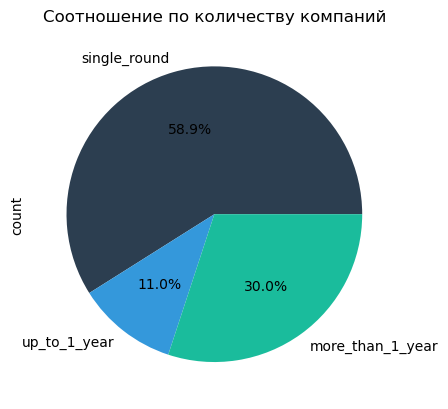

In [26]:
# Визуализируем, какой процент от общего числа компаний относится к каждой из трёх групп
investments_df['financing_group'].value_counts()[order].plot.pie(autopct="%1.1f%%",
                                                                 colors=colors)
plt.title("Соотношение по количеству компаний")
plt.show()

Соотношение по количеству компаний:
- единичное финансирование - 58,9%
- срок финансирования до года - 11%
- срок финансирования более года - 30,1%

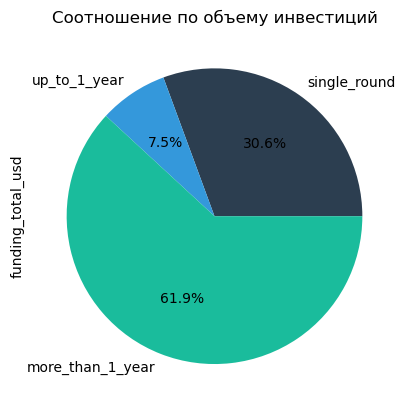

In [27]:
# Суммируем инвестиции по группам
grouped_funding = investments_df.groupby('financing_group')['funding_total_usd'].sum()

# Визуализируем, какую долю от общего объёма привлечённых средств получила каждая группа
grouped_funding[order].plot.pie(autopct="%1.1f%%",
                                colors=colors)
plt.title("Соотношение по объему инвестиций")
plt.show()

Соотношение по объему инвестиций:
- единичное финансирование - 30,6%
- срок финансирования до года - 7,5%
- срок финансирования более года - 61,9%

**Вывод:**
- Большинство компаний (почти 60%) привлекают инвестиции только в одном раунде. Но на их долю приходится лишь 30.6% всех денег.
- Меньшинство компаний (30.1%) имеют длительный цикл финансирования (более года), но они привлекают больше половины всех инвестиций (61.9%).
- Компании со сроком до года — самая малочисленная группа (11%), и они же получают меньше всего денег (7.5%).

Компании с длительным финансированием (больше года) привлекают непропорционально большие объёмы инвестиций, хотя их не так много. Это может говорить о том, что инвесторы вкладывают больше в проекты, которые развиваются долго, или что такие компании проходят через несколько раундов финансирования, каждый раз привлекая крупные суммы.

### 2.2. Выделение средних и нишевых сегментов рынка

In [28]:
# Подсчитаем количество сегментов и сохраним значение в market_counts
market_counts = investments_df[investments_df['market'] != 'unknown']['market'].value_counts()
print(market_counts)

market
software                  4812
biotechnology             3590
mobile                    2344
e-commerce                1866
curated web               1693
                          ... 
chat                         1
ipad                         1
gadget                       1
data center automation       1
gold                         1
Name: count, Length: 394, dtype: int64


Всего определено 394 сегмента.

In [29]:
# Преобразуем market_counts в датафрейм и добавим столбец category
market_df = market_counts.reset_index()
market_df.columns = ['segment', 'count']

In [30]:
# Создадим столбец и присвоим значения категорий
market_df['category'] = 'niche'
for i in range(len(market_df)):
    if market_df.loc[i, 'count'] > 120:
        market_df.loc[i, 'category'] = 'mass'
    elif market_df.loc[i, 'count'] >= 35:
        market_df.loc[i, 'category'] = 'mid'
    else:
        market_df.loc[i, 'category'] = 'niche'
market_df['category'].value_counts()

category
niche    289
mid       57
mass      48
Name: count, dtype: int64

Распределение по сегментам:
- массовые (к которым относится более 120 компаний) - 48
- средние (которые входит от 35 до 120 включительно) - 57
- нишевые - (до 35 компаний) - 289

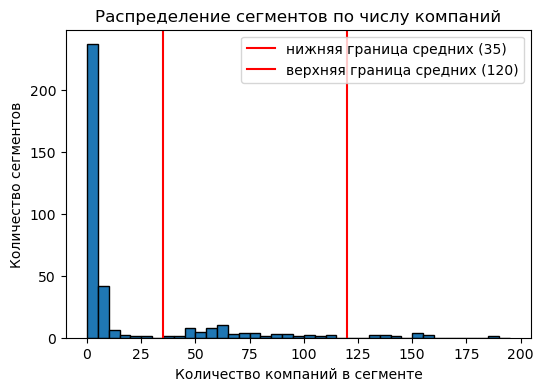

In [31]:
plt.figure(figsize=(6, 4))
plt.hist(market_df['count'], bins=range(0, 200, 5), edgecolor='black')
plt.axvline(x=35, color='red', linestyle='-', label='нижняя граница средних (35)')
plt.axvline(x=120, color='red', linestyle='-', label='верхняя граница средних (120)')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов по числу компаний')
plt.legend()
plt.show()

На гистограмме видно, что основная масса сегментов (289) являются нишевыми — они сосредоточены в интервале 0–35 компаний. Средних сегментов (35–120) — 57. Массовых (>120) — 48. Распределение сильно смещено влево

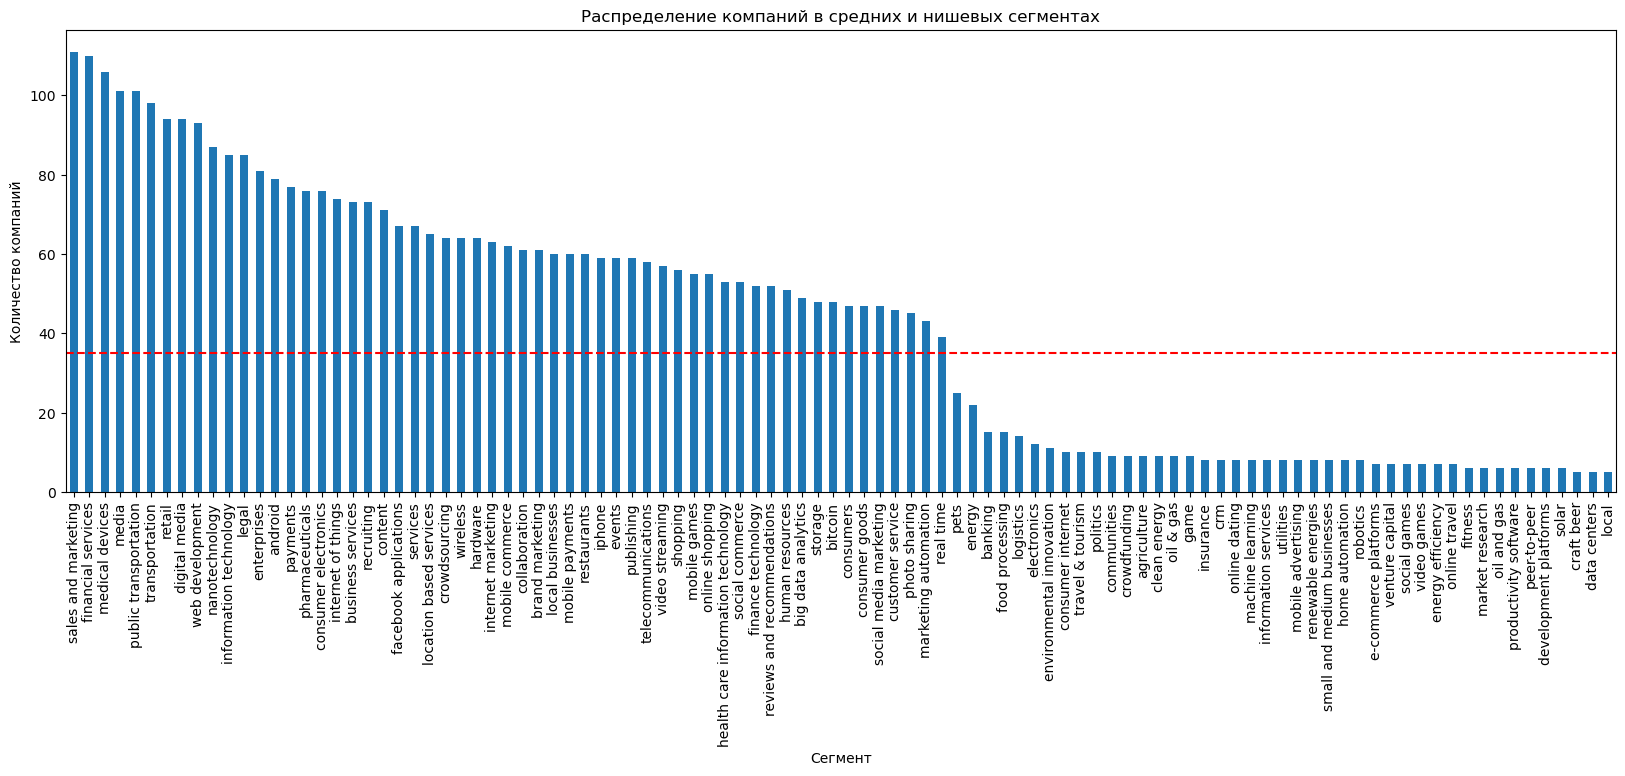

In [32]:
# Визуализируем распределение компаний в средней и нишевой сегментах
filtered_df = market_df[market_df['count'] <= 120]
filtered_df.head(100).plot.bar(title = 'Распределение компаний в средних и нишевых сегментах',
                     x='segment',
                     y='count',
                     legend = False,
                     rot = 90,
                     figsize = (20, 6))
plt.xlabel('Сегмент')
plt.ylabel('Количество компаний')
plt.axhline(y=35, color='r', linestyle='--')
plt.show()

In [33]:
# Минимальное, максимальное и среднее количество компаний для средних сегментов
mid_segments = market_df[market_df['category'] == 'mid']
print(f"Средние сегменты: min={mid_segments['count'].min()}, max={mid_segments['count'].max()}")

# Минимальное, максимальное и среднее количество компаний для нишевых сегментов
niche_segments = market_df[market_df['category'] == 'niche']
print(f"Нишевые сегменты: min={niche_segments['count'].min()}, max={niche_segments['count'].max()}")

# Количество сегментов выше и ниже границы 35 (в отфильтрованном наборе)
above_35 = len(filtered_df[filtered_df['count'] > 35])
below_35 = len(filtered_df[filtered_df['count'] <= 35])
print(f"Количество сегментов в категории средних — {above_35}, в категории нишевых — {below_35}")

Средние сегменты: min=39, max=111
Нишевые сегменты: min=1, max=25
Количество сегментов в категории средних — 57, в категории нишевых — 289


**Вывод:**
- В отфильтрованном наборе (сегменты с количеством компаний ≤ 120) всего 346 сегментов.
- Из них 57 сегментов находятся выше границы 35 — это средние сегменты (от 35 до 120 компаний). Количество компаний в них варьируется от 39 до 111.
- 289 сегментов находятся ниже границы 35 — это нишевые сегменты. В них от 1 до 25 компаний.

In [34]:
# Добавим заглушки niche для нишевых и mid для средних
for i in investments_df.index:
    segment = investments_df.loc[i, 'market']
    
    if segment == 'unknown':
        continue
    
    category = market_df[market_df['segment'] == segment]['category'].values
    
    if len(category) > 0:
        if category[0] == 'mid':
            investments_df.loc[i, 'market'] = 'mid'
        elif category[0] == 'niche':
            investments_df.loc[i, 'market'] = 'niche'
print(investments_df['market'].value_counts())

market
software                4812
mid                     3841
biotechnology           3590
unknown                 2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technol

**Вывод:**
Сегментация рынка позволила выделить ключевые массовые направления (в первую очередь software). Объединение средних и нишевых сегментов в общие группы упростит исследование, не теряя при этом общей картины.

## 3. Работа с выбросами и анализ
### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

In [35]:
# Посмотрим статистику по столбцу funding_total_usd (в млн)
print(investments_df['funding_total_usd'].describe() / 1000000)

count        0.040907
mean        15.912526
std        168.678800
min          0.000001
25%          0.350000
50%          2.000000
75%         10.000000
max      30079.503000
Name: funding_total_usd, dtype: float64


На основе статистики столбца `funding_total_usd`:

- Типичный интервал (между 25-м и 75-м перцентилями): от 0,35 млн до 10 млн долларов.
- Медиана составляет 2 млн долларов, то есть половина компаний привлекли менее 2 млн, половина — более.

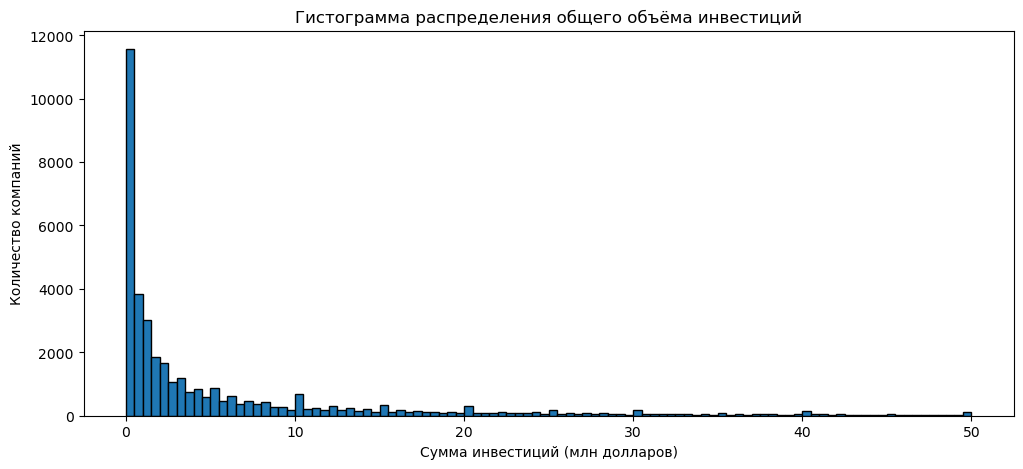

In [36]:
# Визуализируем распределение общего объема инвестиций с ограничением до 50 млн долларов, предварительно переведя значения в млн
plt.figure(figsize=(12, 5))
plt.hist(investments_df['funding_total_usd']/ 1_000_000,
         bins=100,
         range=(0, 50),
         edgecolor='black')
plt.title('Гистограмма распределения общего объёма инвестиций')
plt.xlabel('Сумма инвестиций (млн долларов)')
plt.ylabel('Количество компаний')
plt.show()

**Вывод:**
На гистограмме видно, что подавляющее большинство компаний сосредоточено в левой части диапазона. Основной пик приходится на суммы около 1 млн долларов, после чего количество компаний резко снижается.

Типичные значения общего объёма финансирования визуально оцениваются в интервале примерно от 0 до 10 млн долларов — именно в этой зоне находится основная масса компаний.

In [37]:
# Напишем функцию для определения компаний с аномальным объёмом общего финансирования, используя метод IQR
def iqr_analysis(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return x > upper

In [38]:
# Применим функцию к каждому сегменту
investments_df['is_outlier'] = investments_df.groupby('market')['funding_total_usd'].transform(iqr_analysis)
print(investments_df['is_outlier'].value_counts())

is_outlier
False    35663
True      5244
Name: count, dtype: int64


**Вывод:**
Методом IQR отдельно по каждому сегменту (массовые сегменты индивидуально, средние и нишевые — объединёнными группами `mid` и `niche`) выявлено 5 244 компании с аномальным объёмом финансирования.

In [39]:
# Вычислим процент аномаьных компаний в каждом сегменте
outlier_stats = investments_df.groupby('market').agg(total_companies=('market', 'count'),
                                                     outliers=('is_outlier', 'sum'))
outlier_stats['outlier_percent'] = (outlier_stats['outliers'] / outlier_stats['total_companies'] * 100).round(2)
outlier_stats_sorted = outlier_stats.sort_values('outlier_percent', ascending=False)
print(outlier_stats_sorted[['total_companies', 'outliers', 'outlier_percent']].head(10))

                 total_companies  outliers  outlier_percent
market                                                     
real estate                  279        48            17.20
entertainment                150        25            16.67
consulting                   349        58            16.62
search                       291        48            16.49
cloud computing              152        25            16.45
photography                  204        33            16.18
saas                         272        44            16.18
technology                   238        38            15.97
video                        188        30            15.96
niche                        830       132            15.90


**Вывод:**
- В сегменте `real estate` доля аномалий самая высокая — 17.2%. Это может означать, что в этой отрасли инвестиции распределены крайне неравномерно: небольшая часть компаний привлекает крупные суммы.
- Высокие доли также в `entertainment`, `consulting`, `search`, `cloud computing`, `photography`, `saas`, `technology`, `video`.

### 3.2. Определяем границы рассматриваемого периода, отбрасываем аномалии

In [40]:
# Проверим полноту данных за 2014 года, сверив количество компаний с хотя бы 1 раундом финансирования с 2012 и 2013 годом
ffa2012 = investments_df[investments_df['first_funding_at'].dt.year == 2012].shape[0]
ffa2013 = investments_df[investments_df['first_funding_at'].dt.year == 2013].shape[0]
ffa2014 = investments_df[investments_df['first_funding_at'].dt.year == 2014].shape[0]
print(ffa2012, ffa2013, ffa2014)

5748 7176 6477


In [41]:
# Проверим 2014 год по месяца
ffa_2014 = investments_df[investments_df['first_funding_at'].dt.year == 2014]
by_month = ffa_2014.groupby(ffa_2014['first_funding_at'].dt.month).size()
print(by_month)

first_funding_at
1     810
2     635
3     661
4     593
5     549
6     669
7     671
8     525
9     538
10    492
11    311
12     23
dtype: int64


Данные за 2014 год можно считать полными.

In [42]:
# Удалим из датасета все аномальные компании
investments_df = investments_df[investments_df['is_outlier']== False]

In [43]:
# Проверим количество раундов в каждом году 
investments_df.groupby(investments_df['mid_funding_at'].dt.year)['funding_rounds'].sum()

mid_funding_at
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       43.0
2000.0      113.0
2001.0       66.0
2002.0       98.0
2003.0      125.0
2004.0      181.0
2005.0      948.0
2006.0     1849.0
2007.0     2842.0
2008.0     3663.0
2009.0     4617.0
2010.0     6136.0
2011.0     7578.0
2012.0     9707.0
2013.0    12880.0
2014.0     7122.0
Name: funding_rounds, dtype: float64

Все годы, начиная с 2000, активные (>50 раундов финансирования за год).

In [44]:
# Оставим те компании, у которых mid_funding_at было с 2000 по 2014 год
investments_df = investments_df[investments_df['mid_funding_at'].dt.year.isin(range(2000, 2015))]

### 3.3. Анализ типов финансирования по объёму и популярности

In [45]:
# Посмотрим, у каких типов финансирования какая была сумма денег (сразу в млн)
types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
investments_df[types].sum() / 1000000

seed                      9431.331895
venture                 129092.208088
equity_crowdfunding        237.960645
undisclosed               2100.352252
convertible_note           566.039436
debt_financing            8178.152734
angel                     2481.263836
grant                     1978.848688
private_equity            4843.108504
post_ipo_equity           1946.452068
post_ipo_debt              286.718349
secondary_market            45.285796
product_crowdfunding       186.093920
dtype: float64

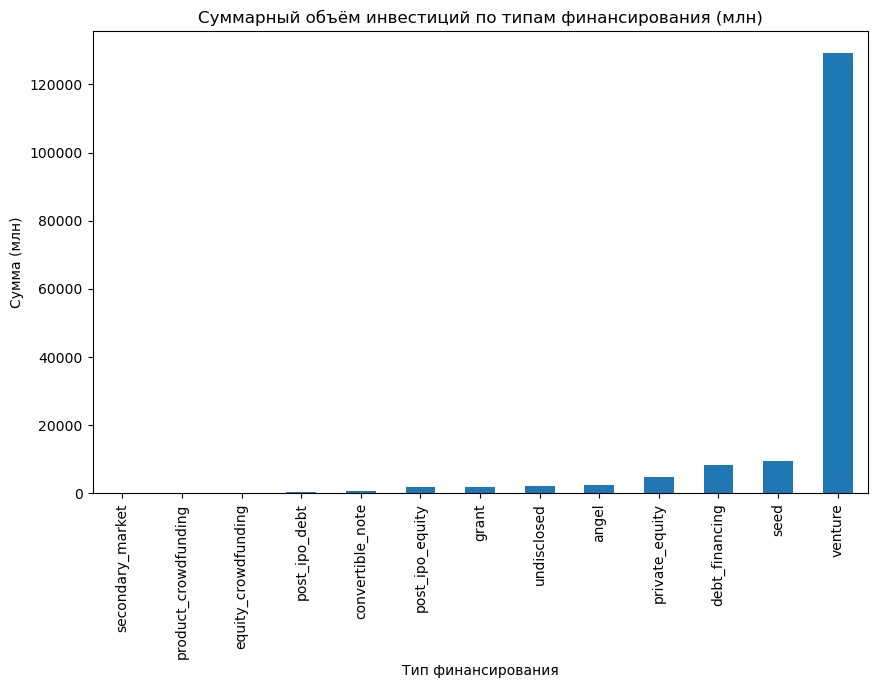

In [46]:
# Визуализируем на графике
sum_mln = investments_df[types].sum() / 1000000
sum_mln.sort_values().plot.bar(title = 'Суммарный объём инвестиций по типам финансирования (млн)',
                               legend = False,
                               figsize = (10, 6))
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма (млн)')
plt.show()

По графику видно, что венчурные инвестиции лидируют с огромным отрывом.

In [47]:
# Теперь оценим, какие типы финансирования чаще всего используются компаниями
most_popular = (investments_df[types] > 0).sum()
print(most_popular)

seed                    13375
venture                 18820
equity_crowdfunding       515
undisclosed               813
convertible_note          521
debt_financing           3265
angel                    2937
grant                    1003
private_equity            634
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
product_crowdfunding      204
dtype: int64


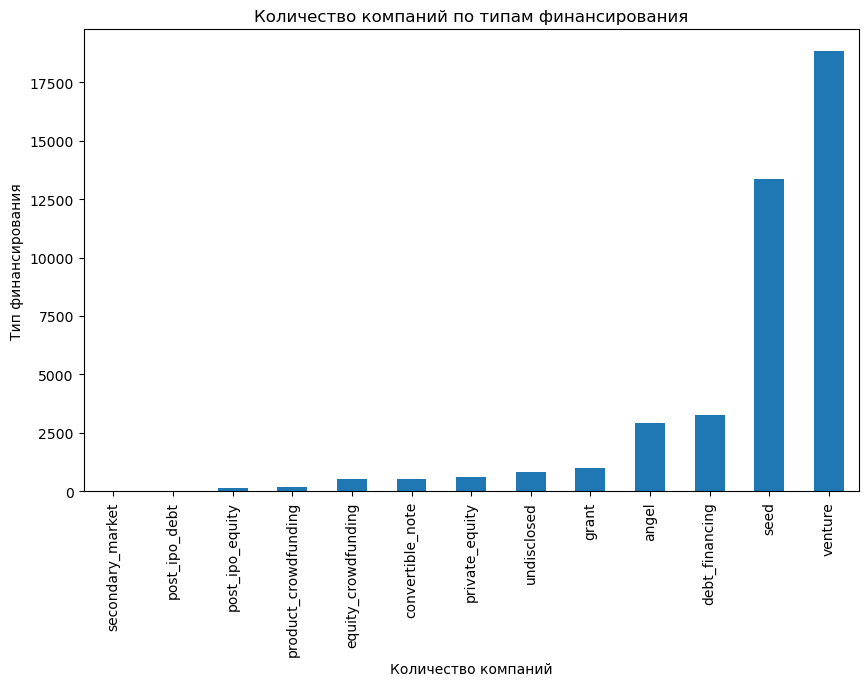

In [48]:
# Визуализируем на графике
most_popular.sort_values().plot.bar(figsize=(10, 6))
plt.title('Количество компаний по типам финансирования')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')
plt.show()

По графику видно, что самыми популярныи инвестициями являются венчурные и посевные.

**Вывод:**

1) Часто используемые типы с небольшими объёмами
- `seed` (посевные) — 13 375 компаний, но всего 9,4 млрд долларов
- `angel` (ангельские) — 2 937 компаний, 2,5 млрд долларов
- `grant` (гранты) — 1 003 компании, 2,0 млрд долларов

2) Редкие типы со значительным объёмом инвестиций

- `private_equity` — всего 634 компании, но 4,8 млрд долларов
- `debt_financing` (долговое) — 3 265 компаний, 8,2 млрд долларов
- `post_ipo_equity` — 164 компании, 1,9 млрд долларов

При этом `venture` — одновременно самый популярный (18 820 компаний) и самый крупный по объёму (129 млрд).

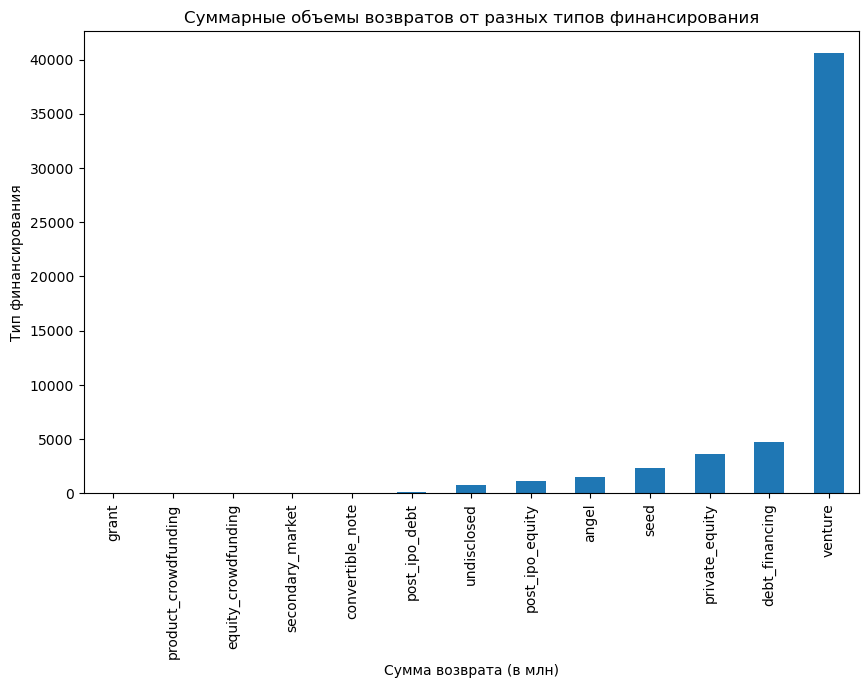

In [49]:
# Оценим суммарные объемы возвратов по разным типа финансирования
returns_df.sum().sort_values().plot.bar(figsize=(10, 6))
plt.title('Суммарные объемы возвратов от разных типов финансирования')
plt.xlabel('Сумма возврата (в млн)')
plt.ylabel('Тип финансирования')
plt.show()

In [50]:
returns_df.sum()

seed                     2382.24
venture                 40578.62
equity_crowdfunding         3.83
undisclosed               730.88
convertible_note           34.79
debt_financing           4734.85
angel                    1509.23
grant                       0.00
private_equity           3587.33
post_ipo_equity          1104.96
post_ipo_debt              91.03
secondary_market            5.20
product_crowdfunding        1.86
dtype: float64

In [51]:
print(returns_df.sum().sort_values(ascending=False))

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


Больше всего сумма возвратов у `venture` (40 579 млн долларов). Далее сумма возвратов по убыванию у `debt_financing` (4 735 млн), `private_equity` (3 587 млн) и `seed` (2 382 млн).

**Вывод:**

1)  Выбросы
На гистограмме видно, что большинство компаний привлекают до 10 млн долларов. Аномально много денег (выбросы) получили 5 244 компании (12.8%). Чаще всего такие крупные суммы встречаются в сегментах `real estate`, `entertainment`, `consulting`.

2) Данные за 2014 год оказались неполными (резкий спад в ноябре–декабре).

3) Типы финансирования
- По объёму — лидирует `venture` (129 млрд), за ним `seed` (9,4 млрд) и `debt_financing` (8,2 млрд).
- По популярности — `venture` и `seed` используют большинство компаний.
- Возвраты — больше всего вернул `venture` (40,6 млрд), затем `debt_financing` (4,7 млрд) и `private_equity` (3,6 млрд). Гранты (`grant`) вернули 0.

Венчурные инвестиции (`venture`) — основа рынка: они самые популярные, дают больше всего денег и возвращают больше всех остальных типов.

## 4. Анализ динамики
### 4.1. Динамика предоставления финансирования по годам

In [52]:
# Рассчитаем средний объем одного раунда финансирования в отдельном столбце
investments_df['avg_funding_per_round'] = (investments_df['funding_total_usd'] / investments_df['funding_rounds']).round(2)

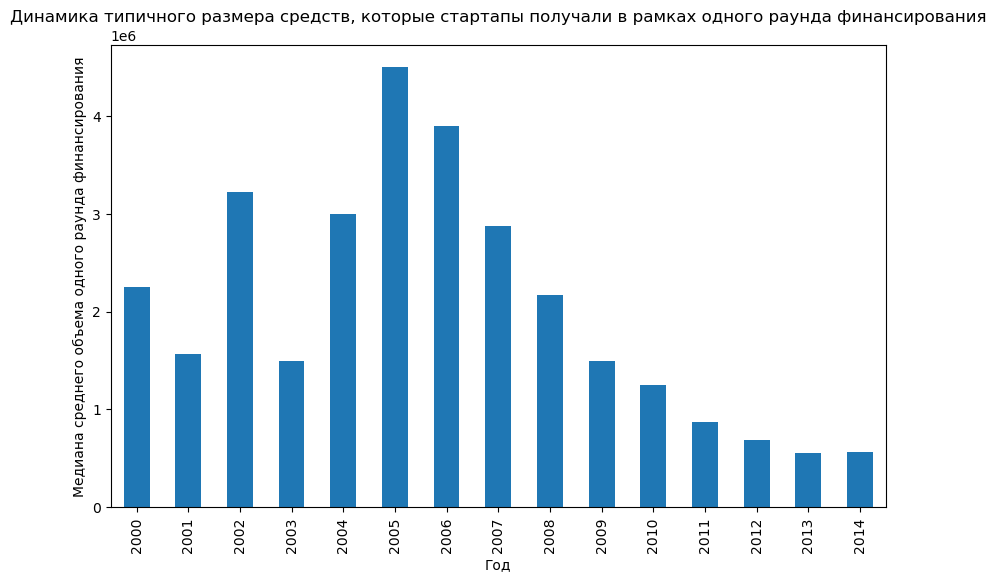

In [53]:
# Оценим динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования
median_funding_per_year = investments_df.groupby(investments_df['mid_funding_at'].dt.year)['avg_funding_per_round'].median()
median_funding_per_year.plot.bar(figsize=(10, 6))
plt.title('Динамика типичного размера средств, которые стартапы получали в рамках одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медиана среднего объема одного раунда финансирования')
plt.show()

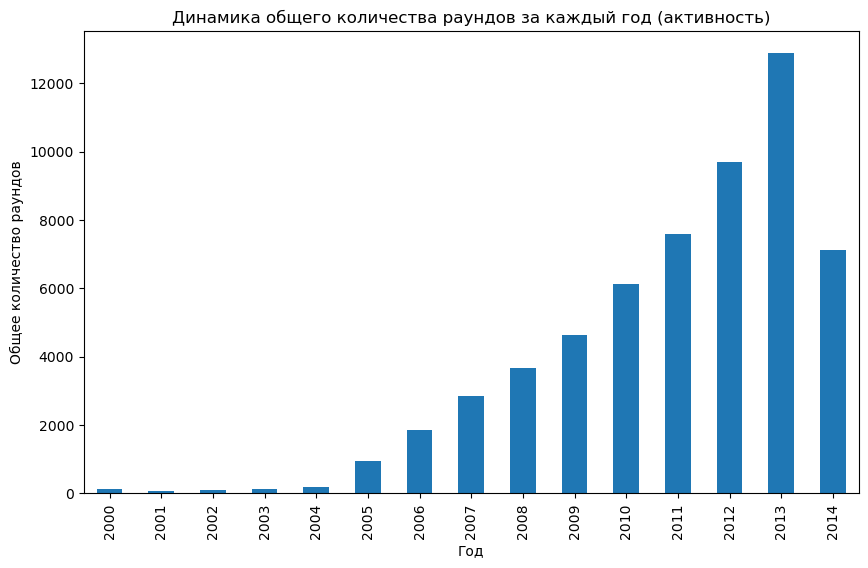

In [54]:
# Оценим динамику общего количества раундов за каждый год (активность)
median_round_per_year = investments_df.groupby(investments_df['mid_funding_at'].dt.year)['funding_rounds'].sum()
median_round_per_year.plot.bar(figsize=(10, 6))
plt.title('Динамика общего количества раундов за каждый год (активность)')
plt.xlabel('Год')
plt.ylabel('Общее количество раундов')
plt.show()

**Вывод:**
1) По графику "Динамика типичного размера средств, которые стартапы получали в рамках одного раунда финансирования" максимум средств, собранных в рамках одного раунда, приходится на 2005 год, далее с каждом годом сумма средств идет на спад с минимум в 2013-2014 гг.

2) По графику "Динамика общего количества раундов за каждый год (активность)" наблюдаем увеличение количества раундов финансирования планомерно с 2000 по 2013 год, но в 2014 году прои сходит резкое снижение почти вдвое.

Таким образом, в 2014 году наблюдается не только снижение количества собранных средств за раунд, но и количество раундов финансирования в целом. Но ранее мы уже обратили внимание на резкое снижение количество первого раунда финансирования в ноябре и декабре 2014 года, поэтому данные за этот год могут быть неполными.

### 4.2. Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [55]:
# Отфильтруем только массовые сегменты и только 2013 и 2014 гг.
filtered_df = investments_df[(investments_df['mid_funding_at'].dt.year.isin([2013, 2014])) &
                             (investments_df['market'] != 'mid') &
                             (investments_df['market'] != 'niche') &
                             (investments_df['market'] != 'unknown')]
year = filtered_df['mid_funding_at'].dt.year
# Построим сводную таблицу и отобразим funding_total_usd в млн долларов
pivot = pd.pivot_table(investments_df,
                       index=year,
                       columns='market',
                       values='funding_total_usd',
                       aggfunc='sum')
pivot = pivot / 1000000
print(pivot)

market          advertising   analytics       apps  automotive   big data  \
mid_funding_at                                                              
2013.0           524.915135  622.821367  28.868621  117.572526  78.698922   
2014.0           207.792333  151.461613  66.237730   69.034162  79.232600   

market          biotechnology  clean technology  cloud computing  consulting  \
mid_funding_at                                                                 
2013.0            5694.269809       1203.060535        84.846778   93.321324   
2014.0            2509.638562        688.686785        73.440856   54.298022   

market          curated web     design  e-commerce   education  \
mid_funding_at                                                   
2013.0           466.495409  60.958835  874.607563  384.311206   
2014.0           241.754277  68.988516  533.728747  231.003308   

market          enterprise software  entertainment     fashion     finance  \
mid_funding_at             

Сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013: `apps`, `big data`, `design`, `internet`, `manufacturing`, `medical`, `real estate`, `saas`, `startups` и `technology`.

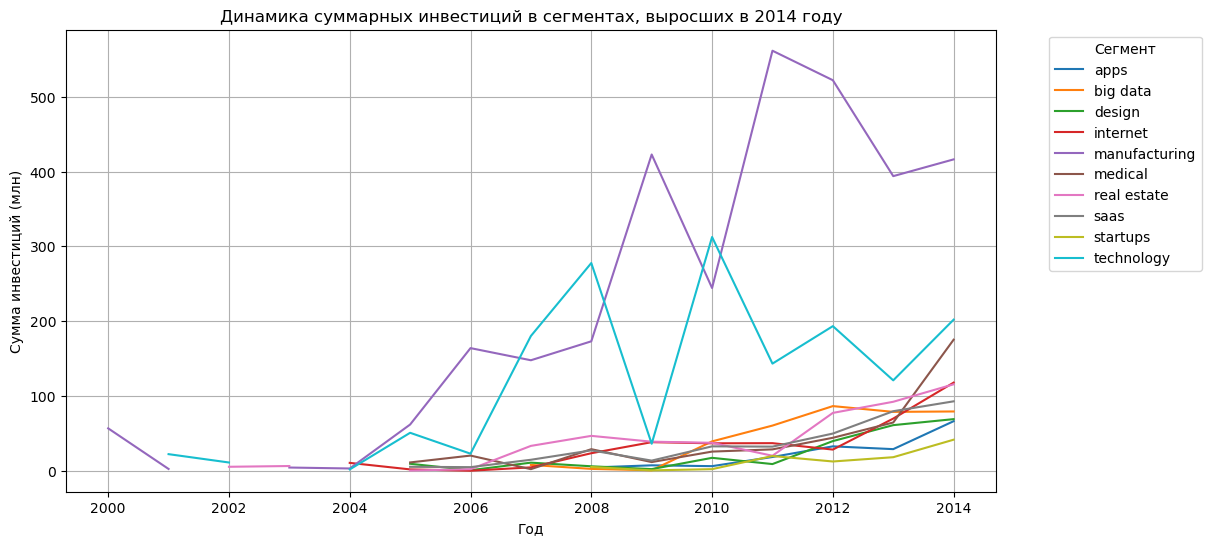

In [56]:
# Возьмем все данные для выбранных сегментов
segments_grow = ['apps', 'big data', 'design', 'internet', 'manufacturing','medical', 'real estate', 'saas', 'startups', 'technology']

# Сводная таблица по всем годам для выбранных сегментов
year = investments_df['mid_funding_at'].dt.year
pivot_full = pd.pivot_table(investments_df[investments_df['market'].isin(segments_grow)],
                            index=year,
                            columns='market',
                            values='funding_total_usd',
                            aggfunc='sum') / 1_000_000

# Построим график по всем годам
pivot_full.plot(figsize=(12, 6))
plt.title('Динамика суммарных инвестиций в сегментах, выросших в 2014 году')
plt.xlabel('Год')
plt.ylabel('Сумма инвестиций (млн)')
plt.legend(title='Сегмент', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.show()

**Вывод:**
- Сегмент `medical` растёт уверенно и плавно и к 2014 году значительно увеличивает объёмы.
- Сегменты `technology` и `manufacturing` показывают нестабильную динамику, но в 2014 году заметно прибавляют.
- Остальные сегменты в целом плавно растут, но ьез значительного увеличения объемов.

### 4.3. Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.
Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например, 1e-60. Это поможет избежать деления на ноль.
Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.
Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [57]:
# Создадим таблицу с суммами финансирования по годам и типам финансирования
all_types = returns_df.columns.tolist()
investments_per_year = investments_df.groupby(investments_df['mid_funding_at'].dt.year)[all_types].sum() / 1000000
print(investments_per_year)

                       seed       venture  equity_crowdfunding  undisclosed  \
mid_funding_at                                                                
2000              16.759140    327.962152             0.000000   112.202640   
2001               2.667675    217.519117             0.000000    36.596784   
2002              10.465192    306.940622             0.000000    42.323731   
2003              15.318355    372.234425             0.000000    10.280000   
2004              18.104728    664.150451             0.000000    62.912359   
2005              39.425198   4809.710779             0.000000     8.871332   
2006              66.794774   9020.604123             0.933057    61.545498   
2007             192.296481  12062.091399             0.000000   109.649902   
2008             302.003020  14234.730391             0.000000   119.920337   
2009             284.351394  14755.360316             2.049671    99.687229   
2010             503.808937  16595.510323           

In [58]:
# Теперь создадим таблицу с долей возвратов по годам и типам финансирования
total = returns_df / (investments_per_year + 1e-60)
print(total)

          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.168922         0.000000e+00     0.697042      0.000000e+00   
2001  1.079592  0.107991         0.000000e+00     0.587483      6.666667e-03   
2002  0.629707  0.682282         0.000000e+00     0.608878      2.000000e+58   
2003  0.505276  0.628260         0.000000e+00     0.914397      1.000000e+58   
2004  0.548476  0.837009         0.000000e+00     0.527559      1.000000e+58   
2005  0.674695  0.546586         0.000000e+00     1.071992      2.000000e+58   
2006  0.925372  0.343678         2.036317e-01     0.759438      1.663181e-01   
2007  0.366153  0.297243         1.000000e+58     0.504971      2.280972e-01   
2008  0.297083  0.190873         3.000000e+58     0.342060      5.978832e-02   
2009  0.563423  0.169517         8.781897e-02     0.376177      5.453492e-02   
2010  0.526648  0.198810         5.27027

In [59]:
# Избавимся от слишком больших значений
total_clean = total.where(total <= 5)
print(total_clean)

          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.168922             0.000000     0.697042          0.000000   
2001  1.079592  0.107991             0.000000     0.587483          0.006667   
2002  0.629707  0.682282             0.000000     0.608878               NaN   
2003  0.505276  0.628260             0.000000     0.914397               NaN   
2004  0.548476  0.837009             0.000000     0.527559               NaN   
2005  0.674695  0.546586             0.000000     1.071992               NaN   
2006  0.925372  0.343678             0.203632     0.759438          0.166318   
2007  0.366153  0.297243                  NaN     0.504971          0.228097   
2008  0.297083  0.190873                  NaN     0.342060          0.059788   
2009  0.563423  0.169517             0.087819     0.376177          0.054535   
2010  0.526648  0.198810             0.0

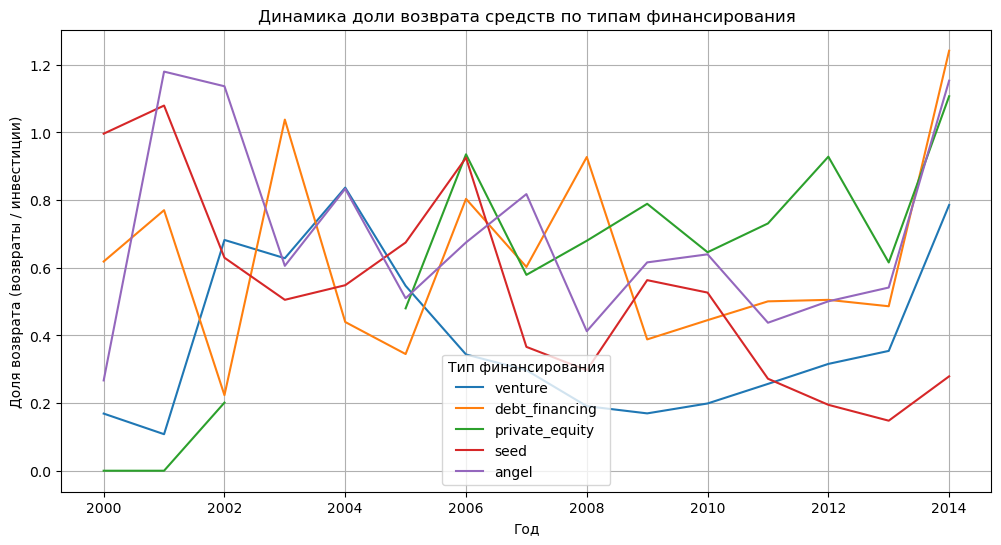

In [60]:
# Построим график для типов финансирования venture, debt_financing, private_equity, seed и angel
types_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
total_clean[types_plot].plot(figsize=(12, 6))
plt.title('Динамика доли возврата средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (возвраты / инвестиции)')
plt.legend(title='Тип финансирования')
plt.grid(True)
plt.show()

**Вывод:**

На графике видно, что динамика доли возврата у всех типов нестабильная: периоды роста сменяются падениями, резких обвалов нет, но плавности тоже нет.

- `venture` — после спада в середине 2000-х к концу периода восстанавливается.
- `debt_financing` — значения колеблются, но в итоге выходят на максимум в 2014 году.
- `angel` — схожая картина: скачки, но финальная точка высокая.
- `seed` — единственный тип, где доля последовательно снижается и не восстанавливается.
- `private_equity` — данные с середины 2000-х, далее с колебаниями растёт.

Устойчивого роста (монотонного или плавного) нет ни у одного типа. Однако `debt_financing`, `venture` и `angel` к 2014 году достигают лучших значений за весь период. `seed` — явно идет хуже всех.

## 5. Итоговый вывод и рекомендации

**Рекомендация заказчику (на 2015 год):**

Исходя из анализа данных за 2000–2014 годы, я бы рекомендовала:

1) Куда инвестировать — в сегмент **`medical`**. Этот сегмент показал наиболее уверенный и плавный рост суммарных инвестиций к 2014 году. В отличие от других массовых сегментов, `medical` не демонстрировал резких спадов и значительно увеличил объёмы финансирования в 2014 году. Также хорошие перспективы у сегмента `technology`, но там динамика менее стабильная.

2) Каким типом финансирования — **`venture`**. Венчурные инвестиции остаются ведущими на рынке: они самые популярные, дают больше всего денег и возвращают больше всех остальных типов. Доля возврата по `venture` к 2014 году выросла и приблизилась к 0,8, что говорит о восстановлении эффективности после спада в конце 2000-х. Альтернативно, можно рассмотреть `debt_financing` — он даёт высокую долю возврата (более 1,2 в 2014 году), но используется реже.

**Итоги проекта:**

Что было сделано:

1. **Предобработка данных** — очистила пропуски и дубликаты, привела типы данных, исправила формат чисел в `funding_total_usd`, заполнила пропуски в `mid_funding_at` как середину между первым и последним раундом, привела названия столбцов к удобному виду.

2. **Инжиниринг признаков** — разделила компании по срокам финансирования (один раунд, до года, более года), классифицировала сегменты рынка на массовые (>120 компаний), средние (35–120) и нишевые (<35), заменила немассовые сегменты на заглушки `mid` и `niche`.

3. **Анализ выбросов** — методом IQR отдельно по каждому сегменту определила компании с аномальным объёмом финансирования (5 244 компании, 12,8%). Чаще всего такие суммы встречаются в сегментах `real estate`, `entertainment`, `consulting`.

4. **Проверка полноты данных** — выяснила, что данные за 2014 год неполные (резкий спад в ноябре–декабре).

5. **Сравнение типов финансирования** — построила графики по объёму, популярности и возвратам. `venture` — лидер по всем параметрам, `seed` и `angel` популярны, но дают небольшие суммы, `debt_financing` и `private_equity` — редкие, но крупные.

6. **Анализ динамики** — выявила, что типичный размер раунда упал после 2005 года, а количество раундов росло до 2013 года, затем снизилось. Сегмент `medical` показал самый уверенный рост среди массовых сегментов.

7. **Оценка возвратов** — рассчитала долю возврата для разных типов финансирования. Устойчивого роста ни у кого нет, но `debt_financing`, `venture` и `angel` к 2014 году вышли на лучшие значения, а `seed` стабильно снижался.


**Основные выводы:**

- Большинство компаний (58,9%) привлекают инвестиции только в одном раунде, но основные деньги (61,9%) получают компании с длительным циклом финансирования (более года).
- Массовых сегментов 48, главный из них — `software` (4 812 компаний).
- `venture` — абсолютный лидер по объёму инвестиций (129 млрд долларов), по возвратам (40,6 млрд) и по популярности (18 820 компаний).
- Данные за 2014 год неполные, поэтому выводы по росту в этом году нужно воспринимать аккуратно.
- Наиболее уверенную динамику инвестиций среди массовых сегментов показывает `medical`.


**Согласованность выводов и сомнения:**

Выводы в целом согласуются: везде `venture` и `medical` находятся в топе, а `seed` показывает ухудшение.

**Что вызывает сомнения:**

1. Неполнота данных за 2014 год могла повлиять на отбор растущих сегментов и на графики динамики.

3. В данных остались университеты и компании с очень старыми датами возникновения, которые могут искажать общую картину.